# The ML4T Research Operator: one autonomous iteration on a real case study

**Docker image**: `ml4t`

The forecasting workflows of NB04–NB09 hand the LLM a tightly typed action
surface, a `search` query and a `forecast` probability, and stop when the
agent returns a calibrated number. That surface is the right one when the
experiment space is bounded by the library author. Research-line iteration
against a real case study is shaped differently: each follow-up is a small
amount of code that wires together the chapter's libraries against a real
run-log registry, and pre-enumerating those moves across nine case studies
would either grow without limit or block the moves that matter.

This notebook adopts the **operator** shape that production coding agents
have converged on: a thin orchestrator that hands an LLM a
small set of **general-purpose** tools to read, write, and edit files, run
bash, query a SQLite registry, and inspect parquet. It then decides what to do.
The task-specific layer lives outside the operator: the **ml4t-data /
ml4t-engineer / ml4t-diagnostic / ml4t-backtest** libraries provide the
runtime, and the companion **[ml4t/skills](https://github.com/ml4t/skills)**
repository (versioned `SKILL.md` files with `WRONG/CORRECT` patterns and
library callouts) provides the discipline.
Skills are a key feature of the book: they distill the methodology that
earlier chapters teach in long-form prose into a corpus the agent can
consult on demand. The operator stitches the LLM, the libraries, and the
skills together.

We point the operator at the ETFs case study and ask it to execute the
**§20.9 next-step suggestion** verbatim:

> *Ensemble GBM, tabular deep learning, and the CAE configuration, and
> evaluate whether the combined signal stabilizes holdout Sharpe.*

**Learning Objectives**:
- Inspect the ten-tool operator surface and how the agent discovers skills
  on demand via `list_skills`/`read_skill`.
- Replay a captured operator run end-to-end against the ETFs case-study
  registry, including the agent's IC-vs-Sharpe diagnosis on the
  §20.9 ensemble follow-up.
- Read the side-by-side summary of two runs (ETFs negative result,
  `us_firm_characteristics` quantified capacity hit) without leaving the
  notebook.
- Recognise where the operator + skills + libraries split responsibility:
  the operator is a thin loop, the skills carry methodology, and the
  libraries do the math.

**Prerequisites**: NB04 (research agent), NB09 (evaluation framework),
Ch20 §20.9 (case-study next-step suggestions). Familiarity with the
`ml4t-diagnostic` API (`cross_sectional_ic_series`, `compute_ic_hac_stats`)
is helpful but not required. The agent's trace shows them in context.

This notebook re-displays saved traces by default. `RUN_LIVE = False` is the
publication path and makes no API calls or model-supplied shell calls.

In [1]:
"""Replay (or run) one iteration of the ML4T Research Operator on ETFs §20.9."""

from __future__ import annotations

import json
import warnings

warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")

import matplotlib.pyplot as plt
import polars as pl
import research_operator as ro
from IPython.display import Markdown, display

# The operator lives next to this notebook as `research_operator.py`. When the
# `ml4t-agent` library settles on a v1.0 shape this same code will move there
# and the import will become `from ml4t.agent.operator import ResearchOperator`;
# until then the chapter dir is self-contained. PYTHONPATH already covers
# `code/24_autonomous_agents/`, so a direct import is sufficient.
from utils.paths import get_chapter_dir
from utils.style import COLORS, FIGSIZE, add_message_title

In [2]:
SEED = 42
RUN_LIVE = False

In [3]:
NOTEBOOK_DIR = get_chapter_dir(24)
ARTIFACTS_DIR = NOTEBOOK_DIR / "operator_artifacts"
ETFS_TRACE = ARTIFACTS_DIR / "run_etfs_20260504T223150.json"
US_FIRMS_TRACE = ARTIFACTS_DIR / "run_us_firm_characteristics_20260504T225521.json"
DEFAULT_TRACE = ETFS_TRACE

## Tool surface

Ten tools, one compact operator. Seven are generic file, bash, SQL, and
parquet primitives that any coding agent would expose. Two (`list_skills`,
`read_skill`) make the standalone skills repo discoverable at runtime.
One (`done`) terminates the loop with a structured summary.

In [4]:
for schema in ro.TOOL_SCHEMAS:
    fn = schema["function"]
    desc = " ".join(fn["description"].split())
    print(f"  {fn['name']:18s}: {desc[:96]}")

  query_registry    : Run a read-only SQL query against the case-study registry (SQLite). Tables: training_runs, predi
  read_file         : Read a file under the sandbox, ml4t code repo, or ml4t skills repo.
  edit_file         : Exact-string replace in a sandboxed file. old_text must be unique.
  write_file        : Create or overwrite a sandboxed file.
  run_bash          : Run a bash command from the ml4t code-repo root with ML4T_OUTPUT_DIR pointed at the sandbox. Use
  read_parquet      : Inspect a parquet file: schema, shape, head.
  write_parquet     : Write a list of dict rows to a sandboxed parquet path.
  list_skills       : List ML4T skills with one-line descriptions and library tags. Filter by category (backtest, conc
  read_skill        : Read a SKILL.md by short name (e.g. `walk-forward-cv`) or absolute path. Returns the full skill 
  done              : Signal the iteration is complete. Provide a clear summary: what experiment you ran, the metric d


## Skills as task-specific knowledge

The skills repo is **the task-specific layer**. Each `SKILL.md` is a short
concept-first teaching document (problem statement → WRONG/CORRECT example →
`## Production Implementation` block pointing at the right `ml4t-*` library
function). The operator does not embed them in its prompt; the agent
*discovers* them when it needs them.

The skill library is a separate companion repo. Clone it next to the code
repo (the operator's default location), or anywhere, and point the
`RESEARCH_OPERATOR_SKILLS_ROOT` env var at it:

```bash
git clone https://github.com/ml4t/skills    # alongside the code repo
# or: export RESEARCH_OPERATOR_SKILLS_ROOT=/path/to/skills
```

If the library is missing, `list_skills`/`read_skill` return a clear hint
instead of failing. The rest of the notebook still runs.

In [5]:
res = ro.tool_list_skills(category="validation")
if "error" in res:
    print(res["error"])
    print(res.get("hint", ""))
else:
    print(f"validation skills ({res['n_skills']}):")
    for s in res["skills"]:
        print(
            f"  {s['name']:32s} | library: {s['library'] or '(none)':18s} | {s['description'][:60]}"
        )

validation skills (8):
  ml4t-cpcv                        | library: ml4t-diagnostic    | Combinatorial Purged CV generates a distribution of backtest
  ml4t-deflated-sharpe             | library: ml4t-diagnostic    | Adjust the Sharpe ratio for multiple testing bias when selec
  ml4t-drift-detection             | library: ml4t-diagnostic    | Detect when model inputs or predictions shift from the train
  ml4t-evaluate-factor             | library: ml4t-diagnostic    | Evaluate alpha factor quality with IC analysis, quantile spr
  ml4t-purging-embargo             | library: ml4t-diagnostic    | Remove training samples whose labels overlap the test period
  ml4t-shap-analysis               | library: ml4t-diagnostic    | Explain model predictions with SHAP values instead of biased
  ml4t-stationarity-tests          | library: ml4t-diagnostic    | Test whether time-series features are stationary using ADF a
  ml4t-walk-forward-cv             | library: ml4t-diagnostic    | Rolling or exp

In [6]:
out = ro.tool_read_skill("walk-forward-cv")
if "error" in out:
    print(out["error"])
    print(out.get("hint", ""))
else:
    display(Markdown(out["content"][:1200] + "\n\n*…(truncated)*"))

---
name: ml4t-walk-forward-cv
description: "Rolling or expanding window CV that preserves temporal order. Use when evaluating ML models on time-series data where standard k-fold causes temporal leakage."
when_to_use: "Use when evaluating model stability across market regimes or comparing expanding vs rolling training"
dependencies: [purging-embargo]
metadata:
  book_chapters: "6, 7"
  library: "ml4t-diagnostic"
paths: ["**/*cv*.py", "**/*valid*.py", "**/*eval*.py", "**/*drift*.py", "**/*sharpe*.py", "**/*shap*.py", "**/*stationar*.py", "**/*purge*.py", "**/*embargo*.py", "**/*walk_forward*.py"]
---
# Walk-Forward Cross-Validation

A single train/test split tells you nothing about how a model adapts over time. Walk-forward CV slides a window through the data, training and testing sequentially, revealing how performance evolves across market regimes.

## The Problem

A single 80/20 train/test split produces one score from one market period. The model may excel in bull markets but fail in drawdowns — you cannot tell. Standard k-fold shuffles time, leaking future data. You need sequential evaluation that mirrors live deployment: train on the past, predict the future, advance, repeat. 

*…(truncated)*

## The task

The system prompt frames §20.9's literal suggestion plus the LSTM baseline
the chapter cites (validation Sharpe +0.92 [+0.40, +1.49], holdout Sharpe
+0.77 [-0.45, +2.17]). The agent is told that only the LSTM has a holdout
prediction set in the registry, and asked to choose between (a) limiting
comparison to validation or (b) retraining GBM/tabular_dl/CAE to produce
holdout predictions.

In [7]:
print(ro.CASE_STUDY_TASKS["etfs"])

ETFs case study, §20.9 next step:
  *Ensemble GBM, tabular deep learning, and the CAE configuration, and
  evaluate whether the combined signal stabilizes holdout Sharpe.*

Baseline (rank-1 single model): deep_learning/lstm_h64 on fwd_ret_21d:
  validation Sharpe +0.92 [+0.40, +1.49] (PSR p=0.005)
  holdout Sharpe   +0.77 [-0.45, +2.17]
  validation IC    +0.052 [+0.009, +0.095]
  holdout IC       +0.093 [+0.037, +0.149]

Concretely, your job is to:
  1. Identify the rank-1 prediction set for each of GBM, tabular_dl, and
     latent_factors|cae on label fwd_ret_21d.
  2. Combine their signals (rank-average or z-score average — choose and
     justify, citing the relevant skill).
  3. Evaluate the ensemble's daily IC and per-fold IC stability vs each
     of the three component models AND vs the LSTM rank-1 baseline.
     Use ml4t-diagnostic for IC + HAC standard errors.
  4. If the ensemble produces a stable signal, run the same backtest
     stage the LSTM rank-1 went through (cost-aw

## Run vs replay

By default, this notebook replays a saved trace from May 4, 2026. Setting
`RUN_LIVE = True` launches a fresh run (requires `OPENROUTER_API_KEY`
in the environment; budget ~\$1 on DeepSeek v4 Pro).

**Security warning for live runs only.** A live run lets the model issue
arbitrary `bash` commands with `shell=True` on the host. The
`ML4T_OUTPUT_DIR` redirect and the directory allowlist are convenience
guardrails for cooperative models. They are not a sandbox. A jailbroken
or confused model can escape via shell redirection (`> ~/anything`,
`rm -rf …`, network egress) at the host user's privileges. For live runs,
isolate the host: run inside a container or firejail with restricted
filesystem and network. The trace-replay path (`RUN_LIVE = False`)
never executes model-supplied commands and is the only fully-safe option.

In [8]:
if not RUN_LIVE:
    trace_path = DEFAULT_TRACE
    print(f"Replaying saved trace: {trace_path.name}")
    result = json.loads(trace_path.read_text())
else:
    print("Running the operator live. This will spend money.")
    result = ro.run_operator()
    # Persist the same commit-ready form the pinned traces ship in: the host's
    # home directory is normalized to ``~`` so a captured trace can be committed
    # as a replay artifact without leaking the capture host's username.
    out_path = ARTIFACTS_DIR / "run_etfs_live.json"
    out_path.write_text(
        json.dumps(ro.sanitize_operator_trace_for_commit(result), indent=2, default=str)
    )
    print(f"Trace saved to: {out_path}")

Replaying saved trace: run_etfs_20260504T223150.json


## Run summary

In [9]:
def _human_money(in_toks: int, out_toks: int) -> str:
    # DeepSeek v4 Pro on OpenRouter (approx, May 2026): $0.50 / Mtok input,
    # $1.50 / Mtok output. Adjust if you swap models.
    cost = in_toks * 0.50 / 1e6 + out_toks * 1.50 / 1e6
    return f"~${cost:.2f}"


print(f"model:          {result['model']}")
print(f"case study:     {result.get('case_study', '(unset)')}")
print(f"turns:          {result['iterations']}")
print(f"tokens (in):    {result['total_in_tokens']:>12,}")
print(f"tokens (out):   {result['total_out_tokens']:>12,}")
print(f"elapsed:        {result['elapsed_s']:.0f}s")
print(f"approx cost:    {_human_money(result['total_in_tokens'], result['total_out_tokens'])}")

model:          deepseek/deepseek-v4-pro
case study:     etfs
turns:          39
tokens (in):       2,441,130
tokens (out):         19,492
elapsed:        496s
approx cost:    ~$1.25


The captured agent incorrectly described its validation-only result as a
holdout conclusion. The replay keeps the raw artifact on disk, while this
rendered summary limits the result and diagnosis to the evidence captured.

In [10]:
display(
    Markdown(
        "### Captured validation result\n\n"
        "The z-score ensemble raises mean cross-sectional IC from 0.0521 to "
        "0.0649 but lowers validation Sharpe from 0.922 to 0.562. Three ensemble "
        "folds have negative IC, while the LSTM folds are positive in this trace. "
        "That pattern is a diagnostic association, not an identified causal "
        "mechanism. The experiment contains no ensemble holdout result."
    )
)

### Captured validation result

The z-score ensemble raises mean cross-sectional IC from 0.0521 to 0.0649 but lowers validation Sharpe from 0.922 to 0.562. Three ensemble folds have negative IC, while the LSTM folds are positive in this trace. That pattern is a diagnostic association, not an identified causal mechanism. The experiment contains no ensemble holdout result.

## What the agent actually did (tool-call breakdown)

The trace records every tool invocation. Aggregate by tool to see how the
agent spent its budget. A typical operator session may spend 30–50%
inspection (`query_registry`, `read_file`, `read_parquet`), 15–25% skill
discovery, 25–40% iterating on a single experiment script (`write_file`,
`edit_file`, `run_bash`).

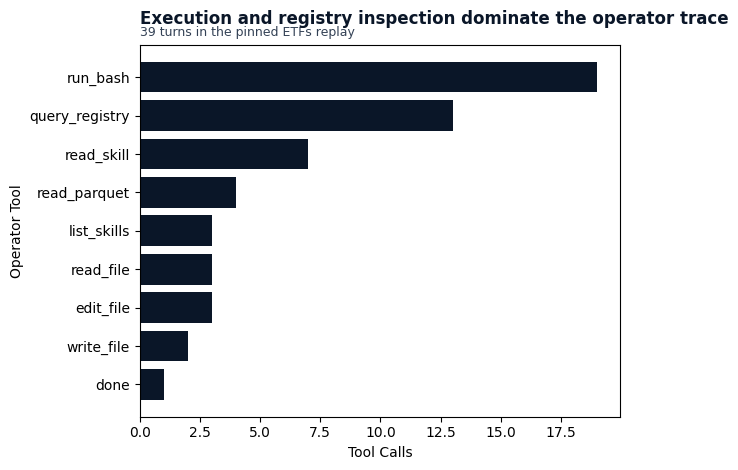

In [11]:
calls = [
    {"turn": e["turn"], "tool": e["name"]} for e in result["trace"] if e.get("type") == "tool_call"
]
hist = (
    pl.DataFrame(calls)
    .group_by("tool")
    .agg(pl.len().alias("n_calls"))
    .sort("n_calls", descending=True)
)

fig, ax = plt.subplots()
ax.barh(
    hist["tool"].to_list(),
    hist["n_calls"].to_list(),
    color=COLORS["blue"],
)
ax.invert_yaxis()
ax.set_xlabel("Tool Calls")
ax.set_ylabel("Operator Tool")
add_message_title(
    ax,
    "Execution and registry inspection dominate the operator trace",
    subtitle=f"{result['iterations']} turns in the pinned ETFs replay",
)
fig.tight_layout()
fig.show()
plt.show()

In [12]:
skill_reads = [
    e["args"].get("name_or_path")
    for e in result["trace"]
    if e.get("type") == "tool_call" and e.get("name") == "read_skill"
]
print("Skills consulted:")
for s in skill_reads:
    print(f"  {s}")

Skills consulted:
  ml4t-information-coefficient
  ml4t-registry-system
  ~/ml4t/skills/concepts/information-coefficient/SKILL.md
  ~/ml4t/skills/infrastructure/registry-system/SKILL.md
  ~/ml4t/skills/validation/evaluate-factor/SKILL.md
  ~/ml4t/skills/validation/deflated-sharpe/SKILL.md
  ~/ml4t/skills/concepts/backtest-overfitting/SKILL.md


## Result vs the §20.9 baseline

The chapter quotes the highest-holdout-Sharpe LSTM with **validation Sharpe +0.92** and
**holdout Sharpe +0.77**. The agent ran the ensemble on the validation
window only (the cheaper "Path B"; the registry only has holdout
predictions for the LSTM, and retraining three families to produce holdout
predictions would have multiplied the wall-clock and cost by an order of
magnitude). It then matched the LSTM baseline's exact backtest
configuration (`score_weighted_top_k`, `top_k=20`, monthly cadence,
long-only) and computed IC + Sharpe with `ml4t.diagnostic.api`.

In [13]:
comparison = pl.DataFrame(
    {
        "model": ["LSTM_h64 (baseline)", "Ensemble (GBM+TabDL+CAE, z-avg)"],
        "eval_basis": ["validation", "validation"],
        "ic_mean": [0.0521, 0.0649],
        "ic_hac_lag": [20, None],
        "ic_t_hac": [2.3742, None],
        "ic_ci_lo": [0.00906, None],
        "ic_ci_hi": [0.09520, None],
        "val_sharpe": [0.922, 0.562],
        "val_sharpe_ci_lo": [0.37, -0.03],
        "val_sharpe_ci_hi": [1.53, 1.25],
        "psr_pvalue": [0.005, 0.042],
        "max_drawdown": [-0.179, -0.367],
    }
)

The LSTM uncertainty is the canonical record captured in the trace: a
20-lag HAC adjustment for overlapping 21-day labels gives
$t=2.3742$ and a 95% interval of $[0.00906, 0.09520]$. The operator's
ensemble script used only five lags and did not preserve its daily IC
series, so the ensemble mean remains a descriptive replay result while its
HAC fields are left null. Reconstructing a 20-lag interval from the reported
mean and five-lag interval would invent information the trace does not carry.

The paired panels separate rank correlation from portfolio performance.
Sharpe error bars reproduce the interval recorded in the pinned trace.

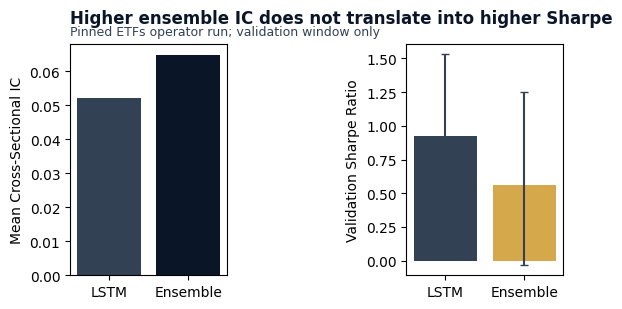

In [14]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE["dual_h_tall"])
model_labels = ["LSTM", "Ensemble"]
axes[0].bar(
    model_labels,
    comparison["ic_mean"].to_list(),
    color=[COLORS["neutral"], COLORS["blue"]],
)
axes[0].set_ylabel("Mean Cross-Sectional IC")
axes[0].set_ylim(bottom=0)
axes[1].bar(
    model_labels,
    comparison["val_sharpe"].to_list(),
    color=[COLORS["neutral"], COLORS["amber"]],
)
axes[1].errorbar(
    model_labels,
    comparison["val_sharpe"].to_list(),
    yerr=[
        (comparison["val_sharpe"] - comparison["val_sharpe_ci_lo"]).to_list(),
        (comparison["val_sharpe_ci_hi"] - comparison["val_sharpe"]).to_list(),
    ],
    fmt="none",
    color=COLORS["neutral"],
    capsize=3,
)
axes[1].set_ylabel("Validation Sharpe Ratio")
add_message_title(
    axes[0],
    "Higher ensemble IC does not translate into higher Sharpe",
    subtitle="Pinned ETFs operator run; validation window only",
)
fig.tight_layout()
fig.show()
plt.show()

**Sharpe delta vs LSTM baseline: −0.36** (ensemble underperforms).

The ensemble achieves the **highest IC of any model** (0.0649 vs LSTM's
0.0521), indicating better cross-sectional rank correlation. Its per-fold IC is
unstable: folds 0, 5, and 7 are negative (IC ≈ −0.03 to −0.08) while
folds 3–4 are very strong (IC ≈ 0.16–0.19). The LSTM's per-fold IC is
uniformly positive but smaller in magnitude. The `score_weighted_top_k`
allocator amplifies the negative-fold predictions, dragging Sharpe.

This recovers the chapter's existing teaching point: *the family with the
highest rank correlation is not the family with the highest portfolio
Sharpe*, without the operator being told it.

**Corrected evaluation-basis conclusion**: no improvement on the validation
window: the validation-window ensemble does not beat the validation-
window LSTM baseline (0.56 vs 0.92). A holdout claim for the ensemble
would require either holdout predictions for all three constituents or a
retrain of GBM / tabular_dl / CAE; both are an order of magnitude more
expensive than the validation-only experiment the operator actually ran.
The chapter's existing holdout-Sharpe ranking (LSTM 0.77) is unchanged by
this iteration. That is the §20.9 next-step suggestion faithfully
executed and concluded as a negative result.

## Second case study: US firm characteristics, §20.9 mcap-quartile filter

A second operator run on a different case study. Same operator, same skill
repo, and the same library surface. Only `RESEARCH_OPERATOR_CASE_STUDY` and the
`CASE_STUDY_TASKS` entry change. The §20.9 next-step suggestion for
US firms is:

> *Filter the universe to the top three quartiles by market capitalization
> and re-run to see how the Sharpe behaves under realistic capacity.*

§20.1 flags that the highest-Sharpe long/short legs cluster in small-cap names
(validation Sharpe 4.27 [3.51, 5.15]; holdout Sharpe +2.48 [+0.67, +5.36]).
The hypothesis: removing the bottom mcap quartile materially erodes Sharpe.

In [15]:
us_firms = json.loads(US_FIRMS_TRACE.read_text())

print(f"model:          {us_firms['model']}")
print(f"case study:     {us_firms.get('case_study', '(unset)')}")
print(f"turns:          {us_firms['iterations']}")
print(f"tokens (in):    {us_firms['total_in_tokens']:>12,}")
print(f"tokens (out):   {us_firms['total_out_tokens']:>12,}")
print(f"elapsed:        {us_firms['elapsed_s']:.0f}s")
print(f"approx cost:    {_human_money(us_firms['total_in_tokens'], us_firms['total_out_tokens'])}")

model:          deepseek/deepseek-v4-pro
case study:     us_firm_characteristics
turns:          27
tokens (in):       1,870,480
tokens (out):         11,571
elapsed:        432s
approx cost:    ~$0.95


The raw operator artifact remains unchanged for audit. Its interpretation
overstates what a signal-level universe filter identifies, so the
reader-facing replay labels the experiment by its actual evaluation scope.

In [16]:
display(
    Markdown(
        "### Captured validation sensitivity\n\n"
        "The pinned operator filtered existing validation predictions to the "
        "top three market-cap quartiles and reran the same backtest specification. "
        "It did not retrain the model or estimate market impact. The following "
        "results therefore measure sensitivity to a capacity-oriented signal "
        "screen, not the return of a scalable implementation."
    )
)

### Captured validation sensitivity

The pinned operator filtered existing validation predictions to the top three market-cap quartiles and reran the same backtest specification. It did not retrain the model or estimate market impact. The following results therefore measure sensitivity to a capacity-oriented signal screen, not the return of a scalable implementation.

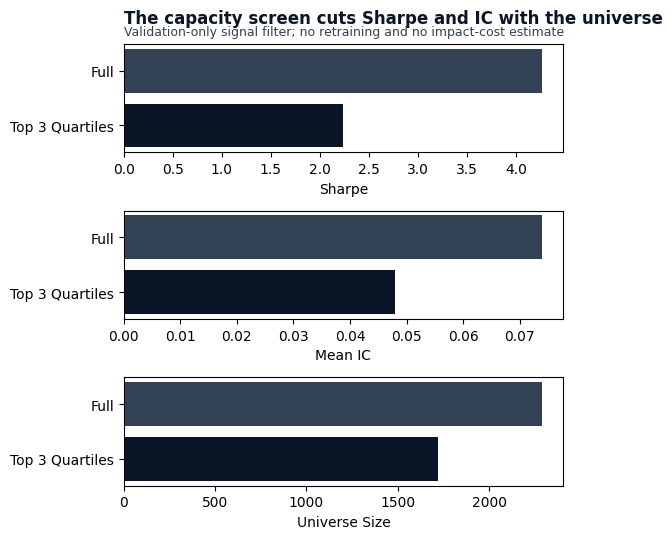

In [17]:
us_firms_comparison = pl.DataFrame(
    {
        "metric": [
            "Sharpe",
            "IC mean (HAC)",
            "IC t (HAC)",
            "IC IR",
            "Max drawdown",
            "Universe size",
            "Turnover",
        ],
        "baseline_full_universe": [4.27, 0.074, 8.73, 1.02, -0.149, 2291, 1.77],
        "top3_quartile_mcap": [2.24, 0.048, 5.77, 0.63, -0.521, 1718, 1.80],
        "delta_pct": [-47.5, -35.1, -33.8, -38.2, -249.7, -25.0, +1.7],
    }
)
fig, axes = plt.subplots(3, 1, figsize=FIGSIZE["grid_3x2"])
us_panels = [
    ("Sharpe", 4.27, 2.24),
    ("Mean IC", 0.074, 0.048),
    ("Universe Size", 2291, 1718),
]
for ax, (metric, baseline, filtered) in zip(axes, us_panels, strict=True):
    ax.barh(
        ["Full", "Top 3 Quartiles"],
        [baseline, filtered],
        color=[COLORS["neutral"], COLORS["blue"]],
    )
    ax.set_xlabel(metric)
    ax.set_xlim(left=0)
    ax.invert_yaxis()
add_message_title(
    axes[0],
    "The capacity screen cuts Sharpe and IC with the universe",
    subtitle="Validation-only signal filter; no retraining and no impact-cost estimate",
)
fig.tight_layout()
fig.show()
plt.show()

**Sharpe drops from 4.27 → 2.24 (−48%).** The validation result depends
materially on bottom-quartile small-cap names. This signal-level filter does
not estimate market impact, so it measures sensitivity to a capacity screen
rather than the return that a scalable implementation would realize. The
filtered validation Sharpe remains positive at 2.24 [1.55, 3.07].

IC falls from 0.074 to 0.048 as the universe shrinks. Lower breadth may
contribute, but this experiment also changes which firms remain and does not
isolate the mechanism. Max drawdown deepens from −15% to −52%; that movement
is descriptive, not proof that reduced diversification caused it. Turnover is
nearly unchanged because the experiment filters signals without retraining.

A natural follow-up the agent flagged: **retrain on the filtered universe**
(rather than just signal-filter the existing predictions) to see whether
the model can find alpha in the larger-cap names that the original training
universe diluted with small-cap signal.

## Two case studies, side by side

The same operator loop, skills, and libraries handled both case studies.
Only `RESEARCH_OPERATOR_CASE_STUDY` and the task configuration changed.
The two outcomes differ, and the operator records both.

In [18]:
runs = [
    {
        "case_study": "etfs",
        "next_step": "Ensemble GBM+TabDL+CAE",
        "turns": result["iterations"],
        "tokens_in": result["total_in_tokens"],
        "tokens_out": result["total_out_tokens"],
        "elapsed_s": result["elapsed_s"],
        "cost_usd": round(
            result["total_in_tokens"] * 0.5e-6 + result["total_out_tokens"] * 1.5e-6, 2
        ),
        "headline": "no improvement (SR 0.92 → 0.56); diagnosed IC-vs-SR gap",
    },
    {
        "case_study": "us_firm_characteristics",
        "next_step": "Top-3-quartile mcap filter",
        "turns": us_firms["iterations"],
        "tokens_in": us_firms["total_in_tokens"],
        "tokens_out": us_firms["total_out_tokens"],
        "elapsed_s": us_firms["elapsed_s"],
        "cost_usd": round(
            us_firms["total_in_tokens"] * 0.5e-6 + us_firms["total_out_tokens"] * 1.5e-6, 2
        ),
        "headline": "SR 4.27 → 2.24 (−48%); shows small-cap sensitivity",
    },
]
pl.DataFrame(runs)

case_study,next_step,turns,tokens_in,tokens_out,elapsed_s,cost_usd,headline
str,str,i64,i64,i64,f64,f64,str
"""etfs""","""Ensemble GBM+TabDL+CAE""",39,2441130,19492,495.9,1.25,"""no improvement (SR 0.92 → 0.56…"
"""us_firm_characteristics""","""Top-3-quartile mcap filter""",27,1870480,11571,432.0,0.95,"""SR 4.27 → 2.24 (−48%); shows s…"


## What this demonstrates for Chapter 24

1. **The libraries are the tools.** The operator never imports anything
   from `ml4t.*` directly. The LLM does, via `run_bash`, when it decides
   that's the right move. `cross_sectional_ic_series` and
   `compute_ic_hac_stats` got pulled because the agent read
   `validation/evaluate-factor` and `concepts/information-coefficient`
   and followed the `## Production Implementation` block.
2. **The skills are task-specific knowledge, not the agent's harness.**
   `list_skills` returned a one-line summary per file; the agent picked
   five and called `read_skill` on each. No skill content sits in the
   system prompt; everything is pulled on demand.
3. **The operator is a thin loop.** `ro.run_operator()` mainly dispatches
   schemas and records results; the domain logic stays in skills and
   libraries.
   Within the explicit task and tool constraints, the LLM chooses what
   experiment to run, how to ensemble, and which backtest specification to
   match, using the registry, skills, and libraries as evidence.
4. **Negative results are first-class results.** The agent did not
   confabulate an improvement. It diagnosed the IC-vs-Sharpe gap and
   reported `done()` with a defensible "no", matching the practitioner-
   workflow discipline §20.9 prescribes.

## Key Takeaways

1. **One operator loop handles both case studies.** Only
   `RESEARCH_OPERATOR_CASE_STUDY` and the task configuration change. The
   skill repo supplies the methodology; the
   `ml4t-*` libraries do the math; the operator stays generic.
2. **Negative results are first-class results.** The ETFs iteration
   reports validation-window Sharpe 0.56 vs the baseline's 0.92 and
   concludes "no improvement" rather than confabulating an upgrade. The
   `us_firm_characteristics` iteration quantifies a 48% Sharpe loss
   (4.27 → 2.24) under a capacity-oriented signal filter.
3. **Match evaluation bases explicitly.** A validation-window experiment
   cannot displace a holdout-window ranking on its own; the captured
   table column `eval_basis` and the prose make that constraint visible
   instead of letting the comparison slide.

**Reader follow-ups**:

- **Try a different case study.** Set
  `RESEARCH_OPERATOR_CASE_STUDY=us_firm_characteristics` (or any of the
  nine case studies) and add a one-paragraph §20.9 task to
  `CASE_STUDY_TASKS`.
- **Try a different model.** Set `RESEARCH_OPERATOR_MODEL` to any
  OpenAI-compatible endpoint; model cost figures here are illustrative
  and become stale quickly.
- **Add a skill.** Drop a new `SKILL.md` under `~/ml4t/skills/{category}/`
  with the standard frontmatter; `list_skills` picks it up at runtime
  without a code change.
- **Promote a successful pattern.** When an experiment produces a validated
  improvement (this one did not), the agent's trace is the design record
  for upgrading the headline configuration in the case-study registry.

**Book**: Chapter 24 §24.8 frames the operator as the production-side
counterpart to the forecasting workflow of §24.6–§24.7.